<a href="https://colab.research.google.com/github/Ray-Mun-Ben/-AI-Coursework-2025/blob/main/Stars_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# File: Stars_Classification_Colab.py
# Usage: paste into Google Colab and run (split into cells if you like)

# --- 1. Imports ---
import os
import numpy as np
import pandas as pd
from collections import Counter

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt

In [ ]:
# --- 2. Load file (tries known path, else ask for upload in Colab) ---
def load_stars():
    paths_to_try = [
        "/mnt/data/Stars (1).csv",
        "/mnt/data/Stars.csv",
        "Stars.csv"
    ]
    for p in paths_to_try:
        if os.path.exists(p):
            print(f"Loaded file from: {p}")
            return pd.read_csv(p)
    # if not found, in Colab you can upload:
    try:
        from google.colab import files
        print("Please upload the dataset file (Stars.csv) when prompted.")
        uploaded = files.upload()
        name = next(iter(uploaded.keys()))
        return pd.read_csv(name)
    except Exception:
        raise FileNotFoundError("Stars dataset not found. Place Stars.csv in working dir or Colab upload.")

df = load_stars()
print("Shape:", df.shape)
print(df.columns.tolist())
display(df.head())

Please upload the dataset file (Stars.csv) when prompted.


Saving Stars.csv to Stars.csv
Shape: (240, 8)
['Temperature (K)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Absolute magnitude (Mv)', 'Star type', 'Star category', 'Star color', 'Spectral Class']


,Temperature (K),Luminosity (L/Lo),Radius (R/Ro),Absolute magnitude (Mv),Star type,Star category,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,0,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,0,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,0,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,0,Brown Dwarf,Red,M


In [ ]:
# --- 3. Quick info and cleaning ---
print("\n--- info() ---")
print(df.info())
print("\n--- describe() (numeric) ---")
display(df.describe(include=[np.number]).T)

# missing values
missing = df.isnull().sum()
print("\nMissing values per column:\n", missing[missing>0])

# drop duplicates
dups = df.duplicated().sum()
print(f"\nDuplicates found: {dups}")
if dups > 0:
    df = df.drop_duplicates()
    print("Dropped duplicates.")

# If there are missing values, drop rows if few; otherwise impute median for numeric.
if missing.sum() > 0:
    small = (missing > 0) & (missing < 0.05 * len(df))  # columns with <5% missing
    cols_to_drop_na = missing[small].index.tolist()
    if len(cols_to_drop_na) > 0:
        df = df.dropna(subset=cols_to_drop_na)
        print(f"Dropped rows with missing values in {cols_to_drop_na}")
    else:
        # impute numeric by median
        num_cols = df.select_dtypes(include=np.number).columns
        for c in num_cols:
            if df[c].isnull().any():
                df[c].fillna(df[c].median(), inplace=True)
        print("Imputed numeric columns with median where needed.")



--- info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (K)          240 non-null    int64  
 1   Luminosity (L/Lo)        240 non-null    float64
 2   Radius (R/Ro)            240 non-null    float64
 3   Absolute magnitude (Mv)  240 non-null    float64
 4   Star type                240 non-null    int64  
 5   Star category            240 non-null    object 
 6   Star color               240 non-null    object 
 7   Spectral Class           240 non-null    object 
dtypes: float64(3), int64(2), object(3)
memory usage: 15.1+ KB
None

--- describe() (numeric) ---


,count,mean,std,min,25%,50%,75%,max
Temperature (K),240.0,10497.462500,9552.425037,1939.00000,3344.250000,5776.0000,15055.5000,40000.00
Luminosity (L/Lo),240.0,107188.361635,179432.244940,0.00008,0.000865,0.0705,198050.0000,849420.00
Radius (R/Ro),240.0,237.157781,517.155763,0.00840,0.102750,0.7625,42.7500,1948.50
Absolute magnitude (Mv),240.0,4.382396,10.532512,-11.92000,-6.232500,8.3130,13.6975,20.06
Star type,240.0,2.500000,1.711394,0.00000,1.000000,2.5000,4.0000,5.00



Missing values per column:
 Series([], dtype: int64)

Duplicates found: 0


In [ ]:
# --- 4. Determine target and features automatically ---
# Prefer categorical column with small unique values
candidate_targets = []
for c in df.columns:
    nunique = df[c].nunique(dropna=False)
    if (df[c].dtype == 'object' or nunique <= 10) and nunique >= 2:
        candidate_targets.append((c, nunique))

candidate_targets = sorted(candidate_targets, key=lambda x: x[1])  # fewest unique first
if candidate_targets:
    target_col = candidate_targets[0][0]
    print(f"Selected target column (categorical candidate): {target_col}")
else:
    # fallback: take last column
    target_col = df.columns[-1]
    print(f"No obvious categorical column found. Using last column as target: {target_col}")

# If target numeric with many unique values, bin into 3 classes
if pd.api.types.is_numeric_dtype(df[target_col]) and df[target_col].nunique() > 10:
    print(f"Target '{target_col}' is numeric with many unique values. Binning into 3 quantile-based classes.")
    df['target_binned'] = pd.qcut(df[target_col], q=3, labels=['low', 'mid', 'high'])
    target_col = 'target_binned'

# If target is object, label-encode it for modeling
if df[target_col].dtype == 'object' or pd.api.types.is_categorical_dtype(df[target_col]):
    le = LabelEncoder()
    df['_target_enc'] = le.fit_transform(df[target_col].astype(str))
    y = df['_target_enc']
    class_names = list(le.classes_)
else:
    y = df[target_col]
    class_names = sorted(y.unique())

print("Target classes:", class_names)
print("Class counts:\n", Counter(y))

# Pick at least two numeric features (exclude target column(s))
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# remove the encoded target if present
num_cols = [c for c in num_cols if c not in (target_col, '_target_enc')]
if len(num_cols) < 2:
    raise RuntimeError("Not enough numeric features found. Please provide at least 2 numeric features.")
# choose two with highest variance
variances = df[num_cols].var().sort_values(ascending=False)
feature_cols = variances.index[:2].tolist()
print("Selected feature columns:", feature_cols)
X = df[feature_cols].copy()

Selected target column (categorical candidate): Star type
Target classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Class counts:
 Counter({0: 40, 1: 40, 2: 40, 3: 40, 4: 40, 5: 40})
Selected feature columns: ['Luminosity (L/Lo)', 'Temperature (K)']


/tmp/ipython-input-3425336122.py:25: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if df[target_col].dtype == 'object' or pd.api.types.is_categorical_dtype(df[target_col]):



--- EDA & Insights ---
1) Class distribution:


,count
Star type,
0,40
1,40
2,40
3,40
4,40
5,40


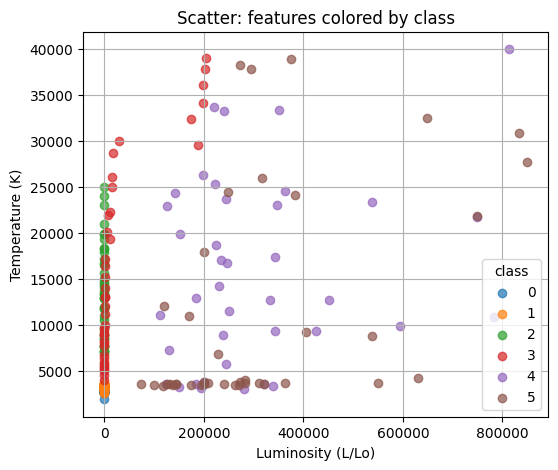

2) Correlation between Luminosity (L/Lo) and Temperature (K): 0.393
3) Mean of features per class:


,Luminosity (L/Lo),Temperature (K)
target,,
0,0.000693,2997.950
1,0.005406,3283.825
2,0.002434,13931.450
3,32067.386275,16018.000
4,301816.250000,15347.850
5,309246.525000,11405.700


Insight A: Class counts show imbalance? {0: 40, 1: 40, 2: 40, 3: 40, 4: 40, 5: 40}
Insight B: Feature 'Luminosity (L/Lo)' mean overall = 107188.362
Insight C: Feature 'Temperature (K)' mean overall = 10497.462
Insight D: Correlation between features = 0.393 (|corr| > 0.5 indicates strong linear relationship)


In [ ]:
# --- 5. EDA & at least 4 insights ---
print("\n--- EDA & Insights ---")
# 1: class distribution
print("1) Class distribution:")
display(pd.Series(y).value_counts())

# 2: scatter plot of the two features colored by class
plt.figure(figsize=(6,5))
for cls in np.unique(y):
    mask = (y == cls)
    plt.scatter(X.loc[mask, feature_cols[0]], X.loc[mask, feature_cols[1]], label=str(cls), alpha=0.7)
plt.xlabel(feature_cols[0]); plt.ylabel(feature_cols[1]); plt.legend(title='class')
plt.title("Scatter: features colored by class"); plt.grid(True); plt.show()

# 3: correlation between selected features
corr = X.corr().iloc[0,1]
print(f"2) Correlation between {feature_cols[0]} and {feature_cols[1]}: {corr:.3f}")

# 4: descriptive stats per class for each feature
print("3) Mean of features per class:")
display(pd.concat([X, pd.Series(y, name='target')], axis=1).groupby('target').mean())

# 5: simple insight statements (at least 4)
insights = [
    f"Insight A: Class counts show imbalance? {dict(Counter(y))}",
    f"Insight B: Feature '{feature_cols[0]}' mean overall = {X[feature_cols[0]].mean():.3f}",
    f"Insight C: Feature '{feature_cols[1]}' mean overall = {X[feature_cols[1]].mean():.3f}",
    f"Insight D: Correlation between features = {corr:.3f} (|corr| > 0.5 indicates strong linear relationship)"
]
for i in insights:
    print(i)


In [ ]:
# --- 6. Train/test split and scaling ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# --- Helper: plot confusion matrix ---
def plot_confusion(cm, title):
    plt.figure(figsize=(4,3))
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.colorbar()
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.show()


Best k (by CV) = 13 with CV accuracy = 0.630


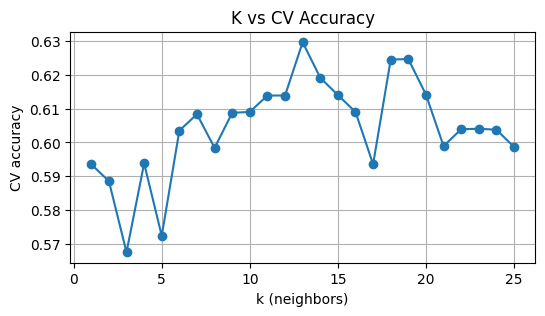


KNN Test Accuracy: 0.6458333333333334
KNN Classification report:
              precision    recall  f1-score   support

           0       0.83      0.62      0.71         8
           1       0.70      0.88      0.78         8
           2       0.62      1.00      0.76         8
           3       0.75      0.38      0.50         8
           4       0.50      0.50      0.50         8
           5       0.57      0.50      0.53         8

    accuracy                           0.65        48
   macro avg       0.66      0.65      0.63        48
weighted avg       0.66      0.65      0.63        48



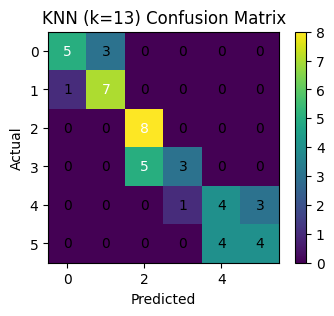

In [ ]:
# --- 7. Model 1: KNN - find best k via CV ---
k_range = list(range(1, 26))
cv_scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_s, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())
best_k = k_range[int(np.argmax(cv_scores))]
print(f"Best k (by CV) = {best_k} with CV accuracy = {max(cv_scores):.3f}")

plt.figure(figsize=(6,3))
plt.plot(k_range, cv_scores, marker='o')
plt.xlabel('k (neighbors)'); plt.ylabel('CV accuracy'); plt.title('K vs CV Accuracy'); plt.grid(True); plt.show()

knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_s, y_train)
y_pred_knn = knn_best.predict(X_test_s)
acc_knn = accuracy_score(y_test, y_pred_knn)
print("\nKNN Test Accuracy:", acc_knn)
print("KNN Classification report:")
print(classification_report(y_test, y_pred_knn))
cm_knn = confusion_matrix(y_test, y_pred_knn)
plot_confusion(cm_knn, f"KNN (k={best_k}) Confusion Matrix")



SVM (default) Test Accuracy: 0.6666666666666666
SVM (default) Classification report:
              precision    recall  f1-score   support

           0       1.00      0.38      0.55         8
           1       0.57      1.00      0.73         8
           2       0.70      0.88      0.78         8
           3       0.57      0.50      0.53         8
           4       0.80      0.50      0.62         8
           5       0.67      0.75      0.71         8

    accuracy                           0.67        48
   macro avg       0.72      0.67      0.65        48
weighted avg       0.72      0.67      0.65        48



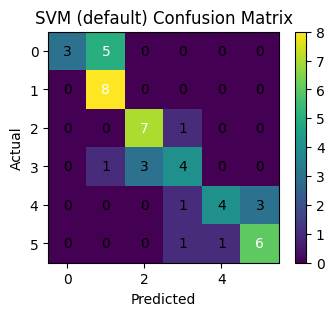

In [ ]:
# --- 8. Model 2: SVM default ---
svm_default = SVC()
svm_default.fit(X_train_s, y_train)
y_pred_svm = svm_default.predict(X_test_s)
acc_svm = accuracy_score(y_test, y_pred_svm)
print("\nSVM (default) Test Accuracy:", acc_svm)
print("SVM (default) Classification report:")
print(classification_report(y_test, y_pred_svm))
cm_svm = confusion_matrix(y_test, y_pred_svm)
plot_confusion(cm_svm, "SVM (default) Confusion Matrix")

In [ ]:
# --- 9. Model 3: Tuned SVM via GridSearchCV ---
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1]
}
svc = SVC()
grid = GridSearchCV(svc, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_s, y_train)
print("\nBest SVM params:", grid.best_params_)
svm_tuned = grid.best_estimator_
y_pred_svm_tuned = svm_tuned.predict(X_test_s)
acc_svm_tuned = accuracy_score(y_test, y_pred_svm_tuned)
print("Tuned SVM Test Accuracy:", acc_svm_tuned)
print("Tuned SVM Classification report:")
print(classification_report(y_test, y_pred_svm_tuned))
cm_svm_tuned = confusion_matrix(y_test, y_pred_svm_tuned)
plot_confusion(cm_svm_tuned, "SVM (tuned) Confusion Matrix")


In [ ]:
# --- 10. Summary comparison ---
print("\n--- Summary ---")
print(f"KNN (k={best_k}) Test Accuracy = {acc_knn:.4f}")
print(f"SVM default Test Accuracy = {acc_svm:.4f}")
print(f"SVM tuned Test Accuracy = {acc_svm_tuned:.4f}")

# show numeric confusion matrices
print("\nKNN confusion matrix:\n", cm_knn)
print("\nSVM default confusion matrix:\n", cm_svm)
print("\nSVM tuned confusion matrix:\n", cm_svm_tuned)

# Optionally save results to CSV for submission
results = pd.DataFrame({
    'model': ['knn', 'svm_default', 'svm_tuned'],
    'accuracy': [acc_knn, acc_svm, acc_svm_tuned]
})
results.to_csv("model_results_summary.csv", index=False)
print("\nSaved summary to model_results_summary.csv")
